# MapMyCells cross-species mapping demonstration and visualization

This notebook shows the results of downloading [this h5ad file](https://datasets.cellxgene.cziscience.com/3a2ccc44-677a-4ee8-9be3-b91cc74f97c4.h5ad), which is a part of [this CellXGene dataset](https://cellxgene.cziscience.com/collections/e1fa9900-3fc9-4b57-9dce-c95724c88716), and mapping it to the Yao et al. 2023 Whole Mouse Brain taxonomy with the MapMyCells webtool.

This dataset was chosen because
- It is Rhesus Macaque data, allowing us to demonstrate the ability of MapMyCells to mape data from one species to a taxonomy from another spies
- The data is annotated with its own taxonomy, allowing us to compare ther results of MapMyCells with the "ground truth" annotations provided by the dataset's authors, thus evaluating the reasonability of MapMyCells' annotations.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm
import matplotlib.gridspec as gridspec
import matplotlib.patches
from mpl_toolkits.axes_grid1 import make_axes_locatable

import anndata
import json
import numpy as np
import pandas as pd
import pathlib

`data_path` below is the path to the downloaded h5ad data file.

**Note:** when I downloaded the file, I renamed it from the alphanumeric gibberish name originally given by CellXGene (which does have the virtue of being unique and version-controlled) to the more human-friendly `dlPFCMacaque.h5ad`.

In [2]:
data_dir = pathlib.Path(
    '/Users/scott.daniel/KnowledgeEngineering/MMC_presentation_260428/data'
)
data_path = data_dir / 'dlPFCMacaque.h5ad'
if not data_path.is_file():
    raise RuntimeError(f"{data_path} is not a valid file")


Below, we inspect the `obs` dataframe of the downloaded data file, noting that cells have been annotated with `class`, `subclass` and `subtype`, which we could use to confirm the believability of the annotations returned by MapMyCells.

In [3]:
data = anndata.read_h5ad(data_path, backed='r')
data.obs

,batch,species,mapped_reads,subtype,subclass,class,tech_rep,assay_ontology_term_id,cell_type_ontology_term_id,development_stage_ontology_term_id,...,# nuclei with RNA assay,tissue_type,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
RMB161_1_AAACCCAAGGAAGTCC,0,Rhesus,4632.0,VLMC COL1A2 VLMCA8,VLMC,NNC,RMB161_1,EFO:0009922,CL:4023051,UBERON:0018241,...,32109,tissue,vascular leptomeningeal cell,10x 3' v3,normal,male,dorsolateral prefrontal cortex,na,prime adult stage,ORqztEdC_4
RMB161_1_AAACCCAAGGACGCAT,0,Rhesus,26407.0,Astro AQP4 SLC1A2,Astro,Glia,RMB161_1,EFO:0009922,CL:0000127,UBERON:0018241,...,32109,tissue,astrocyte,10x 3' v3,normal,male,dorsolateral prefrontal cortex,na,prime adult stage,=Snb5wx7{=
RMB161_1_AAACCCACAAAGCTAA,0,Rhesus,15546.0,Astro AQP4 SLC1A2,Astro,Glia,RMB161_1,EFO:0009922,CL:0000127,UBERON:0018241,...,32109,tissue,astrocyte,10x 3' v3,normal,male,dorsolateral prefrontal cortex,na,prime adult stage,xj6nR`4;va
RMB161_1_AAACCCAGTTACCTGA,0,Rhesus,68135.0,L2-3 CUX2 ACVR1C INHBA,L2-3 IT,ExN,RMB161_1,EFO:0009922,CL:4030059,UBERON:0018241,...,32109,tissue,L2/3 intratelencephalic projecting glutamaterg...,10x 3' v3,normal,male,dorsolateral prefrontal cortex,na,prime adult stage,Q|agu&Z$#_
RMB161_1_AAACCCAGTTTGGCTA,0,Rhesus,5549.0,Micro P2RY12 APBB1IP,Micro,Glia,RMB161_1,EFO:0009922,CL:0000129,UBERON:0018241,...,32109,tissue,microglial cell,10x 3' v3,normal,male,dorsolateral prefrontal cortex,na,prime adult stage,h1rUa%&E+=
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RMB307_4_TTTGTTGCAGTAGAGC,14,Rhesus,39127.0,L2-3 CUX2 NTNG1 PLCH1,L3-5 IT-1,ExN,RMB307_4,EFO:0009922,CL:4030059,UBERON:0018241,...,35601,tissue,L2/3 intratelencephalic projecting glutamaterg...,10x 3' v3,normal,female,dorsolateral prefrontal cortex,na,prime adult stage,BzH#!v?iH7
RMB307_4_TTTGTTGCAGTAGATA,14,Rhesus,3682.0,Oligo MOG FRY,Oligo,Glia,RMB307_4,EFO:0009922,CL:0000128,UBERON:0018241,...,35601,tissue,oligodendrocyte,10x 3' v3,normal,female,dorsolateral prefrontal cortex,na,prime adult stage,5fU-?9xQ<s
RMB307_4_TTTGTTGGTAGGCAGT,14,Rhesus,2924.0,Oligo MOG OPALIN,Oligo,Glia,RMB307_4,EFO:0009922,CL:0000128,UBERON:0018241,...,35601,tissue,oligodendrocyte,10x 3' v3,normal,female,dorsolateral prefrontal cortex,na,prime adult stage,Y%rS?k71cR
RMB307_4_TTTGTTGGTATGAGCG,14,Rhesus,3273.0,Oligo MOG OPALIN,Oligo,Glia,RMB307_4,EFO:0009922,CL:0000128,UBERON:0018241,...,35601,tissue,oligodendrocyte,10x 3' v3,normal,female,dorsolateral prefrontal cortex,na,prime adult stage,RN{ovZm#x}


## Perform the mapping

At this point, you as the user need to upload the h5ad file to the [MapMyCells web app](https://knowledge.brain-map.org/mapmycells/process). Select the `10X Whole Mouse Brain (CCN20230722)` taxonomy and the `Hierarchical algorithm`.

Download the and unzip the resultant `.zip` file. Point `mapping_path` in the cell below to the `.csv` file that comes from unzipping the MapMyCells output package.

In [4]:
mapping_dir = pathlib.Path(
    '/Users/scott.daniel/KnowledgeEngineering/MMC_presentation_260428/mappings/dlPFC'
)
mapping_path = mapping_dir / 'dlPFCMacaque_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1775492008846.csv'
if not mapping_path.is_file():
    raise RuntimeError(f"{mapping_path} is not a valid file")

Now we will load the results of the mapping as a pandas DataFrame and inspect the contents.

In [5]:
result = pd.read_csv(
    mapping_path,
    comment='#'
)

In [6]:
result

,cell_id,class_label,class_name,class_bootstrapping_probability,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
0,RMB161_1_AAACCCAAGGAAGTCC,CS20230722_CLAS_33,33 Vascular,0.89,CS20230722_SUBC_330,330 VLMC NN,0.97,CS20230722_SUPT_1187,1187 VLMC NN_1,1.00,CS20230722_CLUS_5298,5298 VLMC NN_1,5263,0.58
1,RMB161_1_AAACCCAAGGACGCAT,CS20230722_CLAS_30,30 Astro-Epen,1.00,CS20230722_SUBC_319,319 Astro-TE NN,1.00,CS20230722_SUPT_1163,1163 Astro-TE NN_3,1.00,CS20230722_CLUS_5225,5225 Astro-TE NN_3,14939,1.00
2,RMB161_1_AAACCCACAAAGCTAA,CS20230722_CLAS_30,30 Astro-Epen,0.99,CS20230722_SUBC_319,319 Astro-TE NN,0.95,CS20230722_SUPT_1163,1163 Astro-TE NN_3,0.97,CS20230722_CLUS_5225,5225 Astro-TE NN_3,14939,0.82
3,RMB161_1_AAACCCAGTTACCTGA,CS20230722_CLAS_01,01 IT-ET Glut,0.95,CS20230722_SUBC_006,006 L4/5 IT CTX Glut,0.86,CS20230722_SUPT_0027,0027 L4/5 IT CTX Glut_5,0.86,CS20230722_CLUS_0096,0096 L4/5 IT CTX Glut_5,185,0.78
4,RMB161_1_AAACCCAGTTTGGCTA,CS20230722_CLAS_34,34 Immune,0.86,CS20230722_SUBC_334,334 Microglia NN,0.78,CS20230722_SUPT_1194,1194 Microglia NN_1,1.00,CS20230722_CLUS_5312,5312 Microglia NN_1,5283,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131027,RMB307_4_TTTGTTGCAGTAGAGC,CS20230722_CLAS_01,01 IT-ET Glut,0.94,CS20230722_SUBC_006,006 L4/5 IT CTX Glut,0.78,CS20230722_SUPT_0024,0024 L4/5 IT CTX Glut_2,0.37,CS20230722_CLUS_0076,0076 L4/5 IT CTX Glut_2,179,0.36
131028,RMB307_4_TTTGTTGCAGTAGATA,CS20230722_CLAS_31,31 OPC-Oligo,0.95,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,1.00,CS20230722_CLUS_5285,5285 MOL NN_4,5231,1.00
131029,RMB307_4_TTTGTTGGTAGGCAGT,CS20230722_CLAS_31,31 OPC-Oligo,0.88,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,0.96,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.93
131030,RMB307_4_TTTGTTGGTATGAGCG,CS20230722_CLAS_31,31 OPC-Oligo,0.99,CS20230722_SUBC_327,327 Oligo NN,1.00,CS20230722_SUPT_1184,1184 MOL NN_4,0.93,CS20230722_CLUS_5285,5285 MOL NN_4,5231,0.93


Confirm that the cells in the mapping CSV file occur in teh same order as the cells in the original data file (this will make the visualization process easier).

In [7]:
np.testing.assert_array_equal(data.obs.index.values, result.cell_id.values)

## Visualization utilties

Below we define some helper functions that will allow us to generate confusion matrix visualizations.

In [8]:
def create_confusion_matrix(
        row_labels,
        col_labels):
    """
    Create a confusion matrix in which the numerical values are the Jaccard index between the corresponding
    cell type labels.

    Parameters
    ----------
    row_labels:
        an (n_cells, ) array listing the labels of each cell in the cell types that will be along the rows of
        the confusion matrix
    col_abels:
        an (n_cells, ) array listing the labels of each cell in the cell types that will be along the columns
        of the confusion matrix

    Returns
    -------
    A dict
        {'array': the (n_rows, n_cols) confusion matrix (jaccard index)
         'rows': the label of each row (in the order they occur in the array)
         'cols': the label of each column (in the order they occur in the array)
         }
    """
    row_values = np.unique(row_labels)
    col_values = np.unique(col_labels)

    nrows = len(row_values)
    ncols = len(col_values)
    arr = np.zeros((nrows, ncols), dtype=float)
    row_to_idx = {r:ii for ii, r in enumerate(row_values)}
    col_to_idx = {c:ii for ii, c in enumerate(col_values)}
    row_idx = np.array([row_to_idx[r] for r in row_labels])
    col_idx = np.array([col_to_idx[c] for c in col_labels])

    col_set_cache = [
        set(np.where(col_idx==ic)[0])
        for ic in range(ncols)
    ]

    for ir in range(nrows):
        r_set = set(np.where(row_idx==ir)[0])
        for ic in range(ncols):
            c_set = col_set_cache[ic]
            if len(r_set) == 0 and len(c_set) == 0:
                continue
            jj = len(r_set.intersection(c_set))/len(r_set.union(c_set))
            arr[ir, ic] = jj
    return {
        "array": arr,
        "rows": row_values,
        "cols": col_values
    }

In [9]:
def get_confusion_order(input_arr, row_labels, col_labels, col_order):
    """
    Re-order the rows and columns of a confusion matrix. Columns will be ordered
    as specified by the user. Rows will be ordered to try to make the confusion
    matrix look as diagonal as possible.

    Parameters
    ----------
    input_arr:
        the confusion matrix. Probably the Jaccard index between
        two cell types
    row_labels:
        an (n_cells,) array; the labels of each cell along the rows
        of the confusion matrix
    col_labels:
        an (n_cells,) array; the labels of each cell along the
        clumns of the confusion matrix
    col_order:
        an array indicating the order in which you want the columns
        of the confusion matrix to occur

    Returns
    -------
    a dict
        {'rows': np.array of indexes of rows as they should be ordered
         'cols': np.array of indexes of cols as they should be ordered
         }
    """
    col_to_idx = {col: ii for ii, col in enumerate(col_labels)}
    ordered_col_idx = np.array([col_to_idx[col] for col in col_order])

    max_col = np.argmax(input_arr, axis=1)

    ordered_row_idx = []
    for col in ordered_col_idx:
        subset = np.where(max_col == col)[0]
        if len(subset) == 0:
            continue
        if len(subset) == 1:
            ordered_row_idx.append(subset)
            continue
        vals = input_arr[subset, col]
        sorted_dex = np.argsort(vals)[-1::-1]
        this = subset[sorted_dex]
        ordered_row_idx.append(this)
    ordered_row_idx = np.concatenate(ordered_row_idx)

    return {'rows': ordered_row_idx, 'cols': ordered_col_idx}

In [10]:
def plot_confusion_matrix(
        row_assignments,
        col_assignments,
        row_axis_label,
        col_axis_label,
        col_order,
        label_elements=True,
        fontsize=15,
        colorbar_title='Jaccard index',
        axis=None,
        plot_title=None):
    """
    Create a confusion matrix plot colored by the Jaccard index
    to show the correspondence between cell types in two taxonomies.

    Parameters
    ----------
    row_assignments:
        a list of str. One for each cell. The assignment of the cells to the
        cell types listed along the rows of the confusion matrix
    col_assignments:
        as above. The assignment of the cells to the cell types
        listed along the columns of the confusion matrix
    row_axis_label:
        label for the row axis (the vertical axis) of the
        confusion matrix
    col_axis_label:
        label for the column axis (the horizontal axis)
        of the confusion matrix
    col_order:
        the order in which you want the columns to occur in the confusion
        matrix
    label_elements:
        a boolean. If True, label the rows and columns of the confusion
        matrix. If False, do not (probably because there are too many of them)
    color_bar_title:
        title to list along the color bar of the confusion matrix
    axis:
        the matplotlib.Axis in which to plot the confusion matrix
    plot_title:
        optional title for the plot (number of cells in the visualization
        will be appended to to this title)
    fontsize:
        fontsize used for titles and labels in the plot
    """
    n_cells = len(row_assignments)

    confusion = create_confusion_matrix(
        row_labels=row_assignments,
        col_labels=col_assignments
    )
    confusion_matrix = confusion['array']
    row_labels = confusion['rows']
    col_labels = confusion['cols']

    swapping = get_confusion_order(
        input_arr=confusion_matrix,
        row_labels=row_labels,
        col_labels=col_labels,
        col_order=col_order)

    row_labels = np.array(row_labels)[swapping['rows']]
    col_labels = np.array(col_labels)[swapping['cols']]
    
    confusion_matrix = confusion_matrix[swapping['rows'], :]
    confusion_matrix = confusion_matrix[:, swapping['cols']]

    heatmap_axis = axis
    if plot_title is not None:
        full_title = f'{plot_title}'
    else:
        full_title = None
    if full_title is not None:
        full_title = f'{full_title} -- {n_cells:.2e} cells'
    else:
        full_title = f'{n_cells:.2e} cells'
    heatmap_axis.set_title(full_title, fontsize=fontsize)
    img = heatmap_axis.imshow(
        np.ma.masked_array(confusion_matrix, confusion_matrix==0.0),
        cmap=matplotlib.cm.Reds,
        aspect='auto'
    )

    divider = make_axes_locatable(heatmap_axis)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    col_hist_axis = divider.append_axes("bottom", size="5%", pad=0.05)
    row_hist_axis = divider.append_axes("left", size="5%", pad=0.05)
    cbar = fig.colorbar(
        img,
        ax=heatmap_axis,
        cax=cax,
        label=colorbar_title)

    cbar.ax.tick_params(axis='both', which='both', labelsize=fontsize)
    cbar.ax.set_ylabel(ylabel=colorbar_title, fontdict={'fontsize': fontsize+5})
    heatmap_axis.tick_params(
        which='both',
        axis='both',
        size=0,
        labelsize=0
    )
    
    col_hist_axis.set_xlabel(col_axis_label, fontsize=fontsize+5)
    row_hist_axis.set_ylabel(row_axis_label, fontsize=fontsize+5)

    for axis, assignments, labels, orientation in [(row_hist_axis, row_assignments, row_labels, 'horizontal'),
                                                   (col_hist_axis, col_assignments, col_labels, 'vertical')]:
        l_to_idx = {l: ii+0.5 for ii, l in enumerate(labels)}
        assn_idx = [l_to_idx[a] for a in assignments if a in l_to_idx]
        _ = axis.hist(assn_idx, bins=np.arange(len(labels)+1), orientation=orientation)
        if label_elements:
            ticks = [ii for ii in range(len(labels))]
            axis.set_xticks(ticks, labels, va='top', ha='left')
            axis.tick_params(
                which='both',
                axis='both',
                labelsize=fontsize-3
            )
            axis.tick_params(
                axis='x',
                labelrotation=-90.0
            )

    row_hist_axis.set_ylim((0, len(row_labels)))
    col_hist_axis.set_xlim((0, len(col_labels)))
    
    row_hist_axis.yaxis.set_inverted(True)

    if label_elements:
        row_ticks = [ii+0.5 for ii in range(len(row_labels))]
        row_hist_axis.set_yticks(row_ticks, labels=row_labels, va='center', ha='right')
        row_hist_axis.set_xticks([])
        row_hist_axis.tick_params(
            which='both',
            axis='x',
            labelsize=0
        )

        col_ticks = [ii for ii in range(len(col_labels))]
        col_hist_axis.set_xticks(col_ticks, labels=col_labels, va='top', ha='left')
        col_hist_axis.tick_params(
            which='both',
            axis='x',
            pad=0
        )
        col_hist_axis.set_yticks([])
        col_hist_axis.tick_params(
            which='both',
            axis='y',
            labelsize=0
        )
        col_hist_axis.tick_params(axis='x', rotation=-45.0)
    else:
        row_hist_axis.tick_params(
            axis='x',
            size=0,
            labelsize=0
        )
        row_hist_axis.tick_params(
            axis='y',
            labelsize=fontsize
        )
        col_hist_axis.tick_params(
            axis='y',
            size=0,
            labelsize=0
        )
        col_hist_axis.tick_params(
            axis='x',
            labelsize=fontsize
        )

        ticks = range(20, len(row_labels), 20)
        tick_labels = [f'{ii}' for ii in ticks]
        row_hist_axis.set_yticks(ticks, tick_labels)
        ticks = range(20, len(col_labels), 20)
        tick_labels = [f'{ii}' for ii in ticks]
        col_hist_axis.set_xticks(ticks, tick_labels)


## Visualize mapping results

First compare the ground truth "subclass" annotations with the Whole Mouse Brain "class" annotations found by MapMyCells. Recall that for this example we have mapped Rhesus Macaque data to a Whole Mouse Brain taxonomy. The two sets of labels appear to have good biological correspondence.

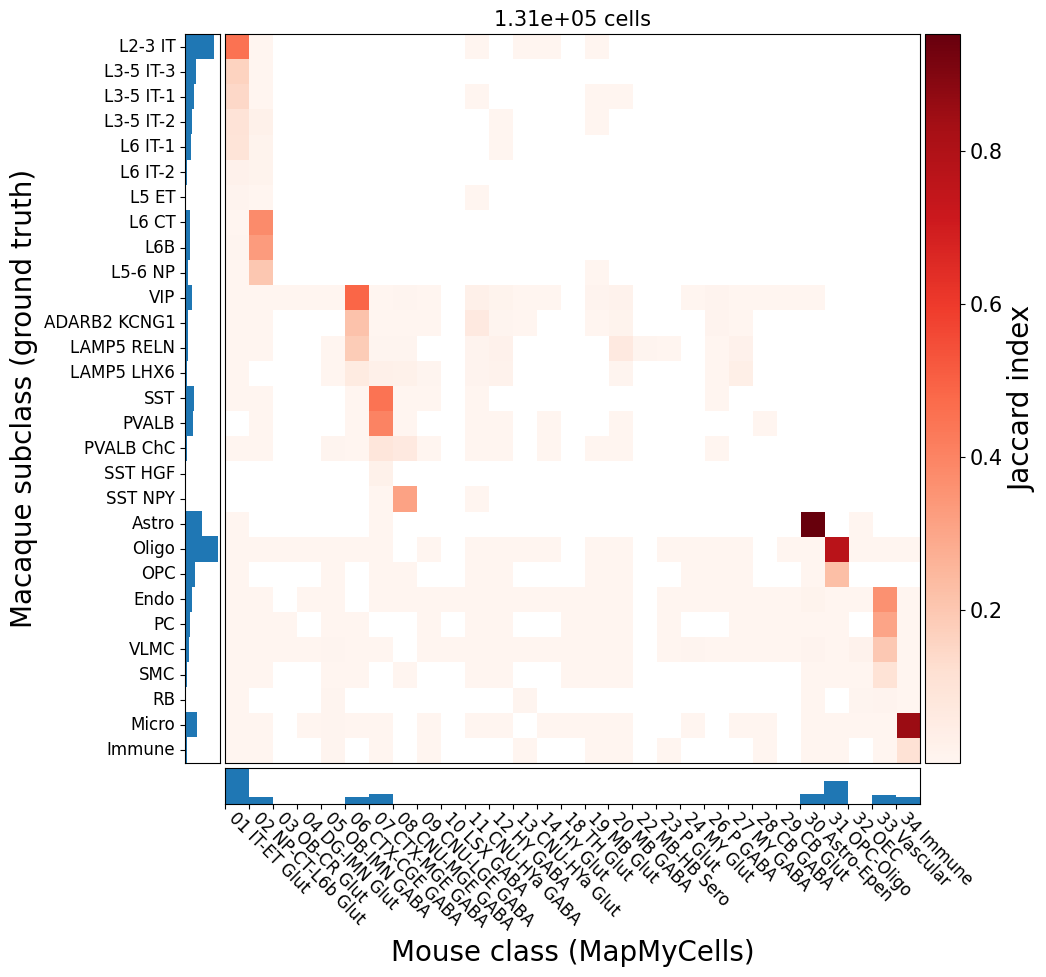

In [11]:
fig = plt.figure(figsize=(10, 10))
axis = fig.add_subplot(1,1,1)
_ = plot_confusion_matrix(
    row_assignments=data.obs.subclass.values,
    col_assignments=result.class_name.values,
    row_axis_label='Macaque subclass (ground truth)',
    col_axis_label='Mouse class (MapMyCells)',
    label_elements=True,
    plot_title=None,
    axis=axis,
    col_order=np.unique(result.class_name.values)
)

Now let's perform a QC cut, only accepting "class" level mappings with `bootstrapping_probability > 0.5`. Cutting on this quality metric significantly reduces the off-diagonal noise the confusion matrix without sacrificing very many cells from the dataset.

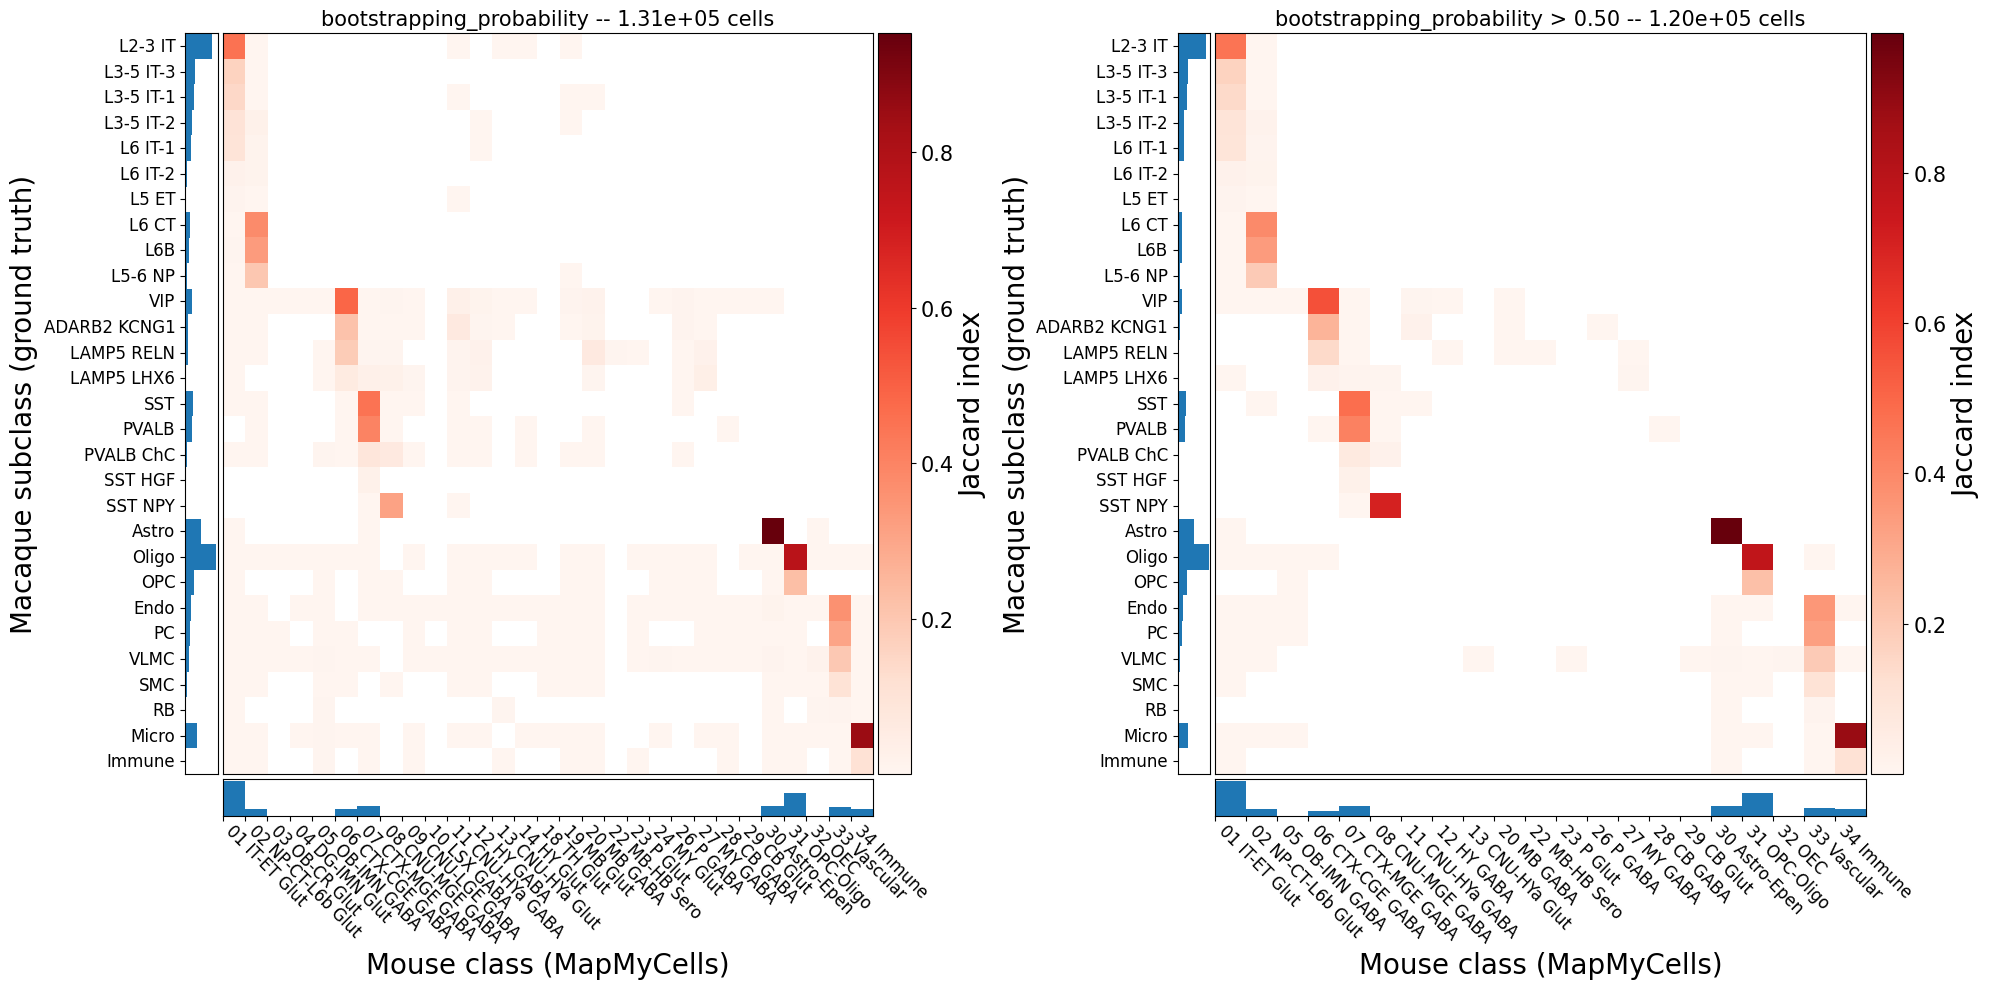

In [12]:
fig = plt.figure(figsize=(20, 10))
axis_list = [fig.add_subplot(1, 2, ii+1) for ii in range(2)]
_ = plot_confusion_matrix(
    row_assignments=data.obs.subclass.values,
    col_assignments=result.class_name.values,
    row_axis_label='Macaque subclass (ground truth)',
    col_axis_label='Mouse class (MapMyCells)',
    label_elements=True,
    plot_title=f'bootstrapping_probability',
    axis=axis_list[0],
    col_order=np.unique(result.class_name.values),
    fontsize=15
)
prob_threshold = 0.5
mask = (result.class_bootstrapping_probability.values>prob_threshold)
_ = plot_confusion_matrix(
    row_assignments=data.obs.subclass.values[mask],
    col_assignments=result.class_name.values[mask],
    row_axis_label='Macaque subclass (ground truth)',
    col_axis_label='Mouse class (MapMyCells)',
    label_elements=True,
    plot_title=f'bootstrapping_probability > {prob_threshold:.2f}',
    axis=axis_list[1],
    col_order=np.unique(result.class_name.values[mask]),
    fontsize=15
)
fig.tight_layout()

Compare ground truth "subtype" mappings with Whole Mouse Brain "subclass" mappings found by MapMyCells, only accepting cells with `bootstrapping probability > 0.5` at both the "class" and "subclass" level. Again: we find that ~ 85% of the cells from the original dataset occur in a very diagonal confusion matrix.

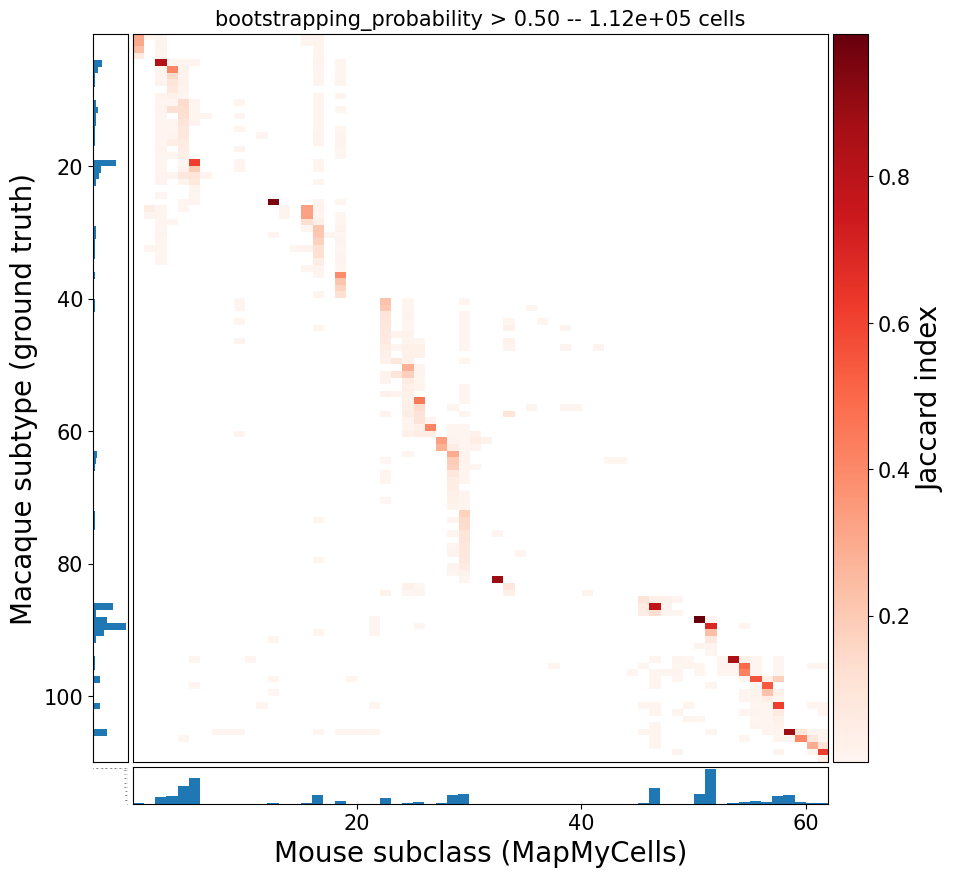

In [13]:
fig = plt.figure(figsize=(10, 10))
mask = np.logical_and(
    result.class_bootstrapping_probability.values>0.5,
    result.subclass_bootstrapping_probability.values>0.5
)
axis = fig.add_subplot(1,1,1)
_ = plot_confusion_matrix(
    row_assignments=data.obs.subtype.values[mask],
    col_assignments=result.subclass_name.values[mask],
    row_axis_label='Macaque subtype (ground truth)',
    col_axis_label='Mouse subclass (MapMyCells)',
    label_elements=False,
    plot_title=f'bootstrapping_probability > {prob_threshold:.2f}',
    axis=axis,
    col_order=np.unique(result.subclass_name.values[mask])
)